## Import libraries

In [1]:
import yaml
import os
import boto3
import pandas as pd
from pprint import pprint
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np


import warnings
warnings.filterwarnings("ignore")

In [2]:
def read_yaml_file(path, file):
    with open(os.path.join(path, file)) as f:
        try:
            content = yaml.safe_load(f)
        except yaml.YAMLError as e:
            raise e
    
    return content


CONFIG_PATH = os.path.join("..", "src", "config")

In [3]:
credentials = read_yaml_file(path=CONFIG_PATH, file="credentials.yaml")
settings = read_yaml_file(path=CONFIG_PATH, file="settings.yaml")

AWS_ACCESS_KEY = credentials['AWS_ACCESS_KEY']
AWS_SECRET_KEY = credentials['AWS_SECRET_KEY']

RAW_FILE_NAME = settings["RAW_FILE_NAME"]

In [4]:
# Inittials S3 client (for low-level operations)
s3_client = boto3.client(
    's3',
    aws_access_key_id = AWS_ACCESS_KEY,
    aws_secret_access_key = AWS_SECRET_KEY
)
if not os.path.exists(RAW_FILE_NAME):
    s3_client.download_file('bucket6502-aws', RAW_FILE_NAME, RAW_FILE_NAME)

## Exploratory Data Analysis (EDA)

In [5]:
df = pd.read_csv(RAW_FILE_NAME)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

### Check Duplicated Rows

In [6]:
# Check for duplicated rows, marking all occurrences of duplicates as True
pprint(f"Number of duplicated rows: {df.duplicated(keep=False).sum()}")

'Number of duplicated rows: 0'


### Check Label Distribution

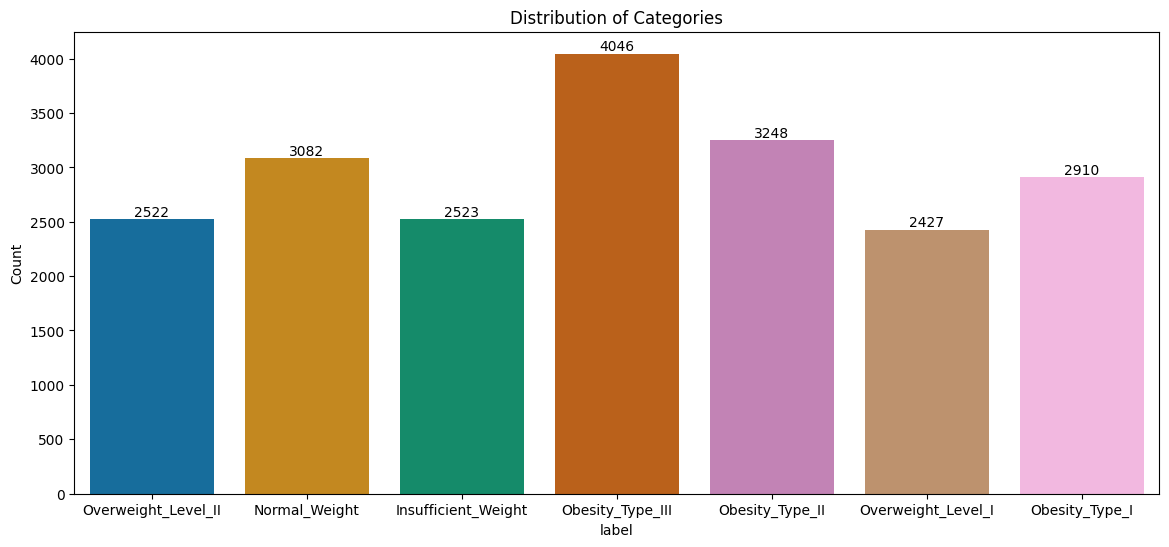

In [8]:
plt.figure(figsize=(14,6))
ax = sns.countplot(
    data=df,
    x='NObeyesdad',
    palette=sns.color_palette("colorblind")
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Categories')
plt.xlabel('label')
plt.ylabel('Count')
plt.show()

In [9]:
df["NObeyesdad"].value_counts() / df.shape[0]

NObeyesdad
Obesity_Type_III       0.194913
Obesity_Type_II        0.156470
Normal_Weight          0.148473
Obesity_Type_I         0.140187
Insufficient_Weight    0.121544
Overweight_Level_II    0.121495
Overweight_Level_I     0.116919
Name: count, dtype: float64

### Checking NAN values

In [10]:
df.isna().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

### Check Categorical Columns Values Distribution

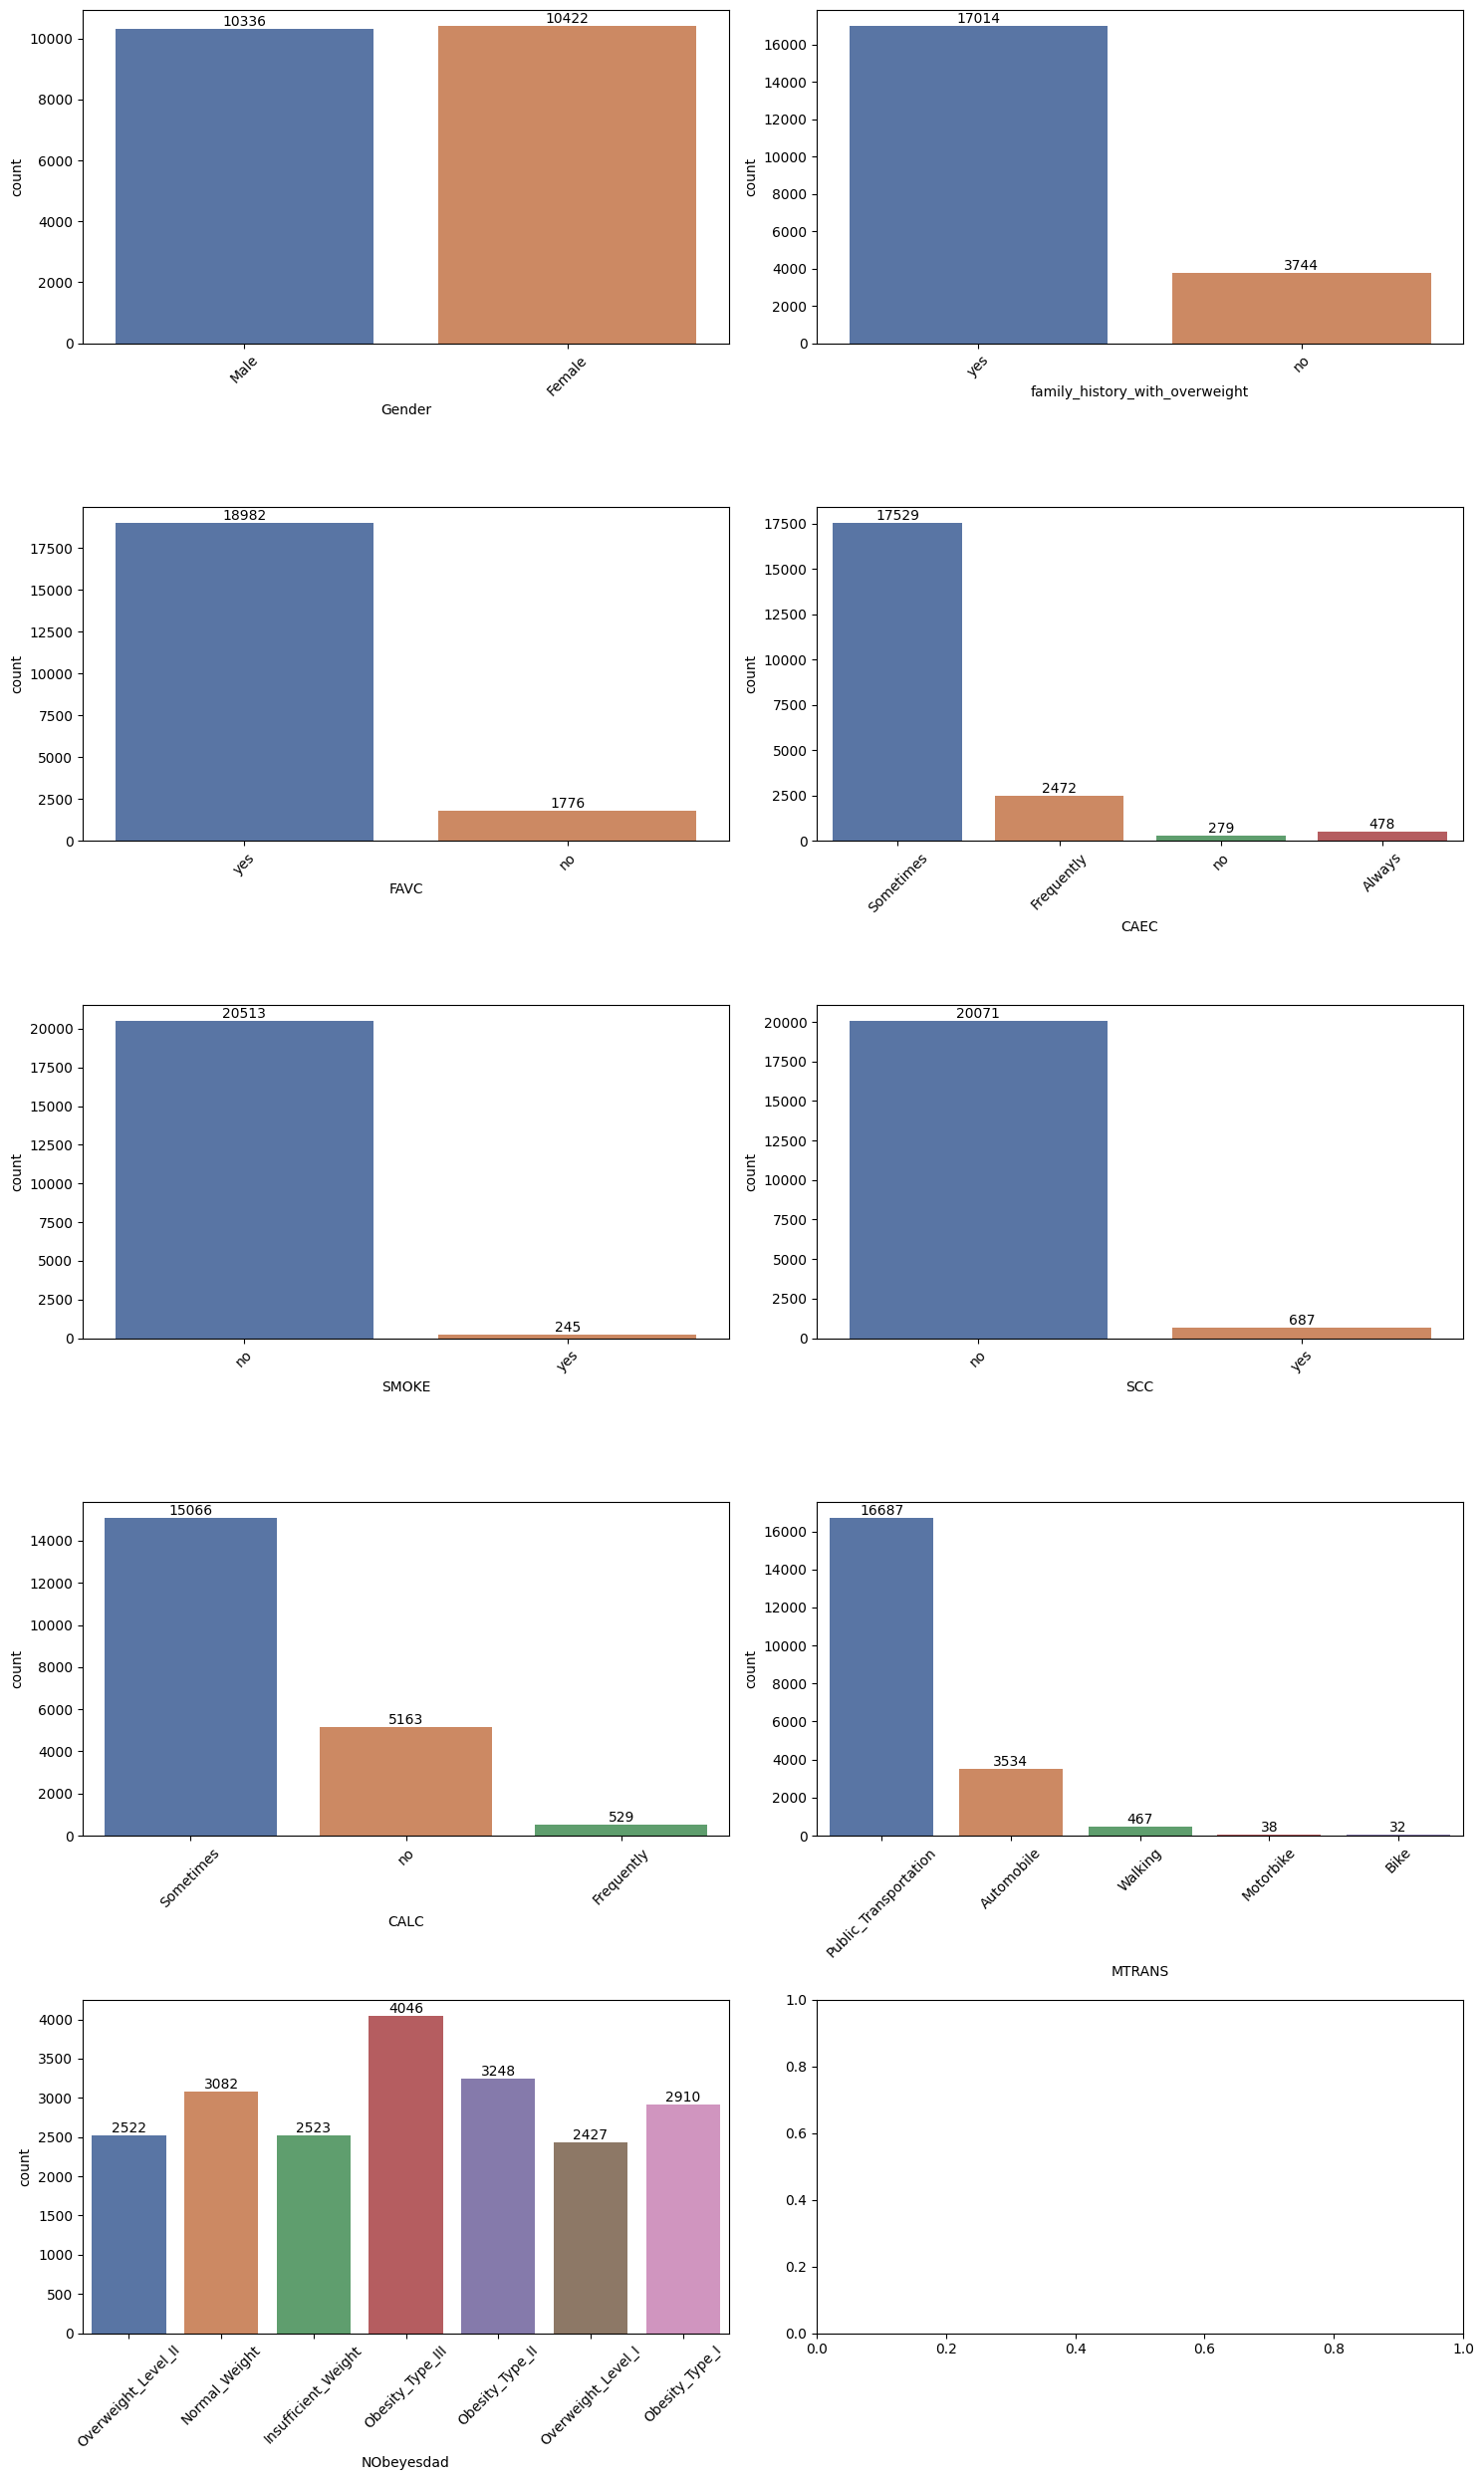

In [11]:
categorical_columns = df.select_dtypes(include=["object"]).columns.to_list()

cols = 2
rows = math.ceil(len(categorical_columns) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, c in enumerate(categorical_columns):
    ax = axes[i]

    sns.countplot(
        data=df,
        x=c,
        ax=ax,
        palette=sns.color_palette('deep')
    )

    for container in ax.containers:
        ax.bar_label(container)

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Check Numerical Columns Distributions

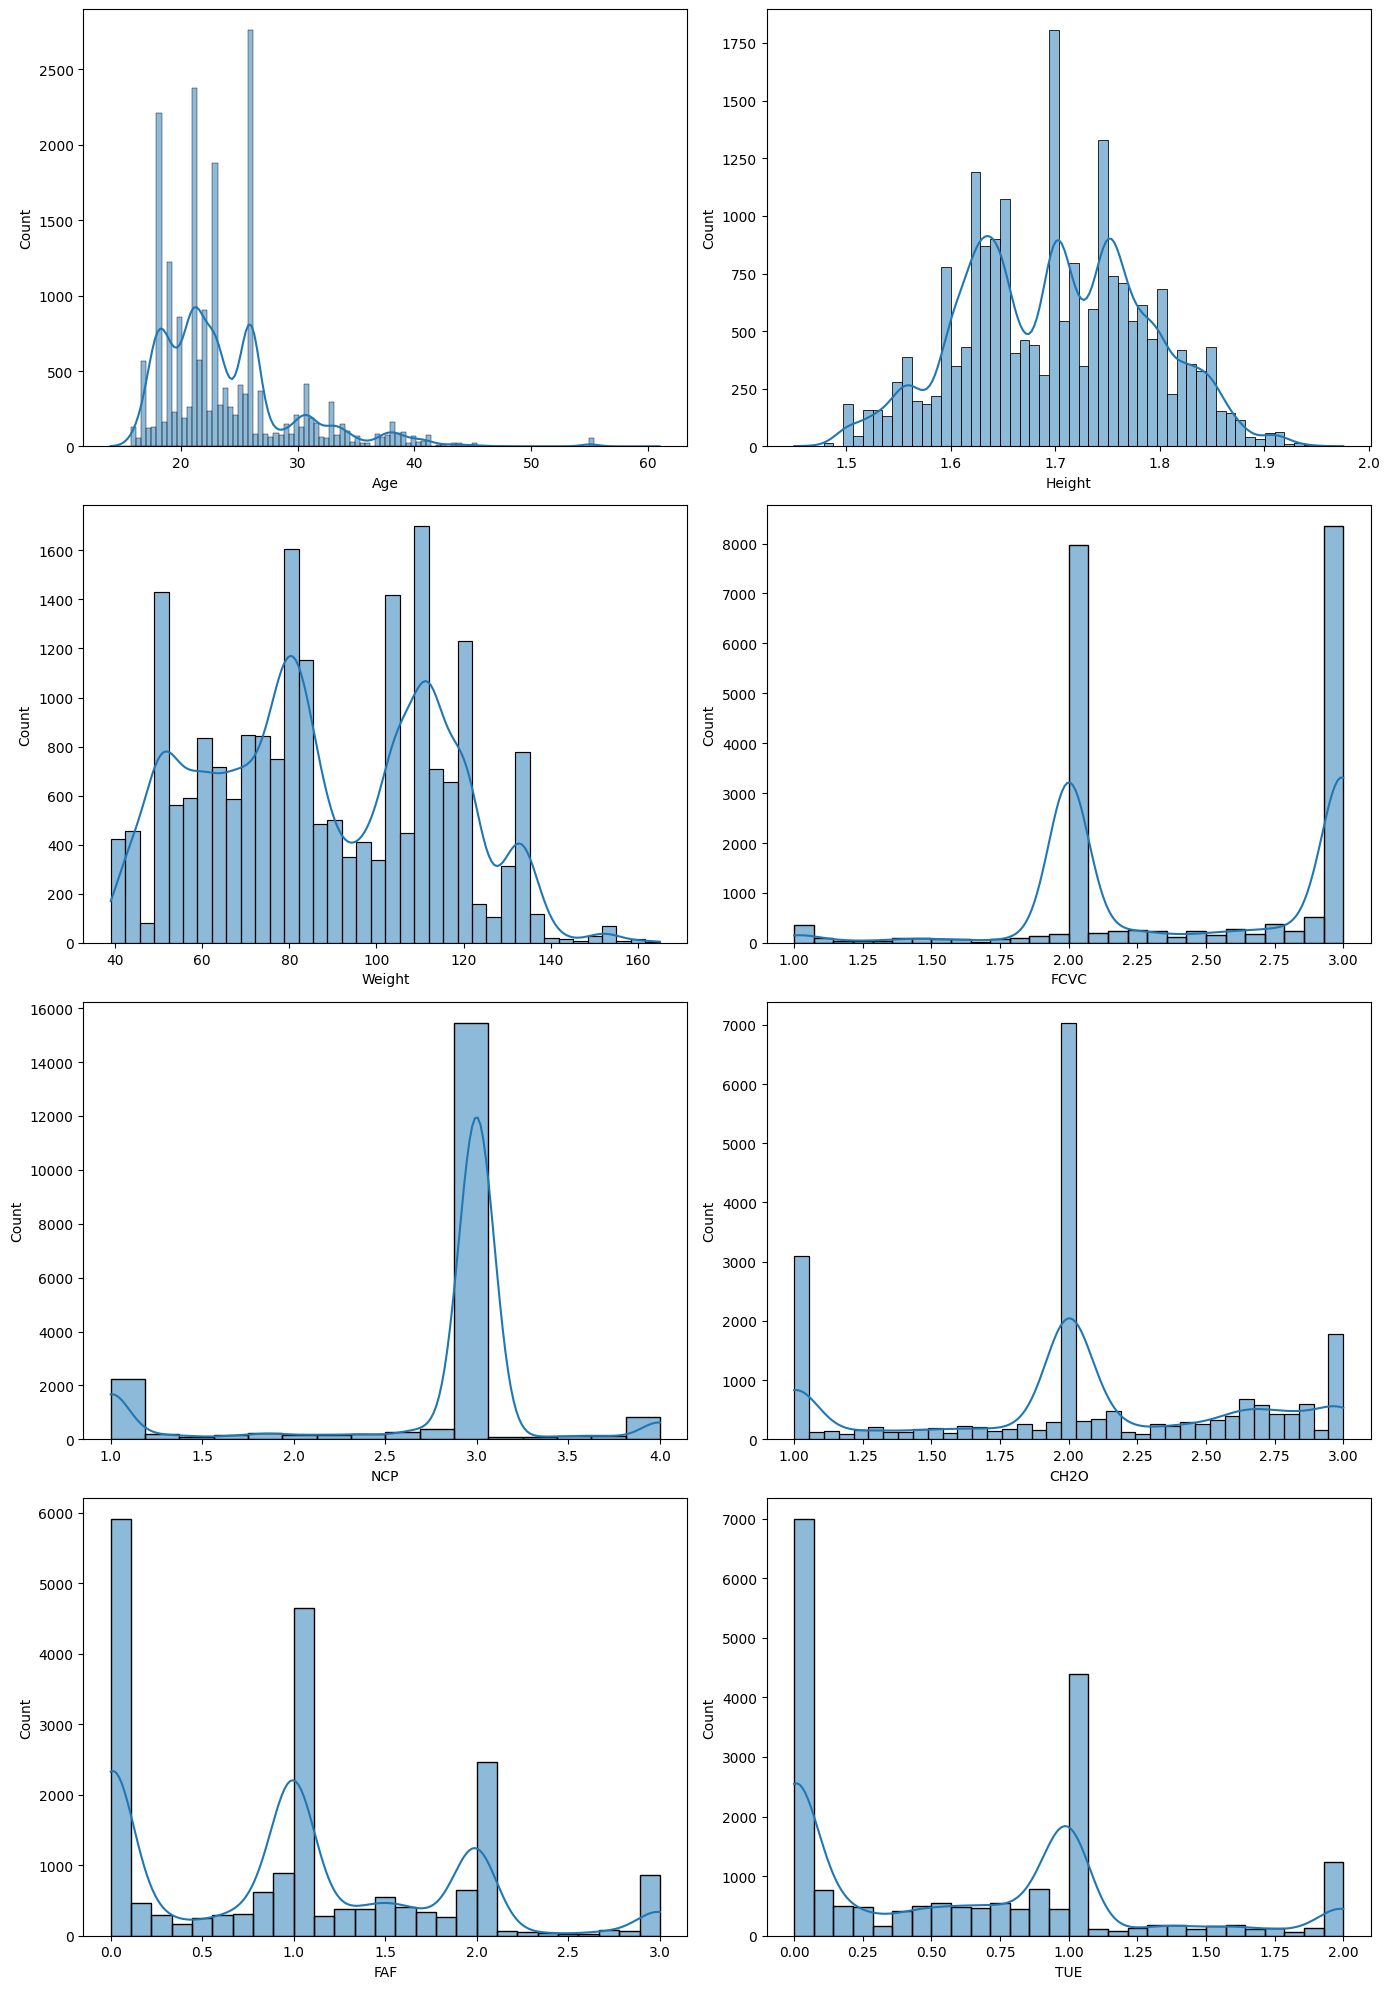

In [12]:
numerical_columns = df.select_dtypes(include=['number']).columns.to_list()
numerical_columns.remove('id')

cols = 2
rows = math.ceil(len(numerical_columns) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(14, 5*rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.histplot(
        data=df,
        x=col,
        ax=ax,
        kde=True
    )

plt.tight_layout()
plt.show()


In [13]:
print("Numerical Columns skewness:")
pprint(df[numerical_columns].skew()); print()

print("Numerical Columns variation:")
pprint(df[numerical_columns].var()); print()

print("Numerical Columns standard deviation:")
pprint(df[numerical_columns].std()); print()

Numerical Columns skewness:
Age       1.586252
Height    0.015803
Weight    0.093187
FCVC     -0.356611
NCP      -1.562253
CH2O     -0.212506
FAF       0.505726
TUE       0.670411
dtype: float64

Numerical Columns variation:
Age        32.354163
Height      0.007623
Weight    695.875017
FCVC        0.284322
NCP         0.497553
CH2O        0.370232
FAF         0.702750
TUE         0.362541
dtype: float64

Numerical Columns standard deviation:
Age        5.688072
Height     0.087312
Weight    26.379443
FCVC       0.533218
NCP        0.705375
CH2O       0.608467
FAF        0.838302
TUE        0.602113
dtype: float64



### Check Numerical Columns Correlations Between Each Other

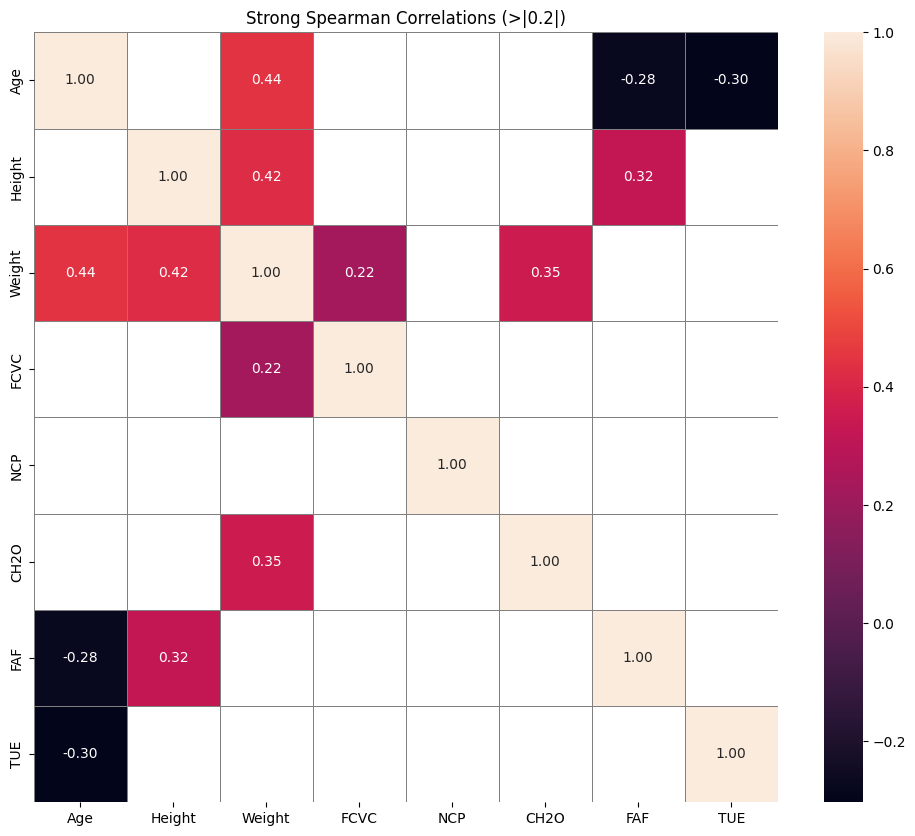

In [14]:
corr_matrix = df[numerical_columns].corr(method='spearman')

mask_strong = np.abs(corr_matrix) >= 0.2

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    mask=~mask_strong,
    linewidths=0.5,
    linecolor='gray'
)
plt.title(f"Strong Spearman Correlations (>|0.2|)")
plt.show()

### Check Numerical Columns Outliers

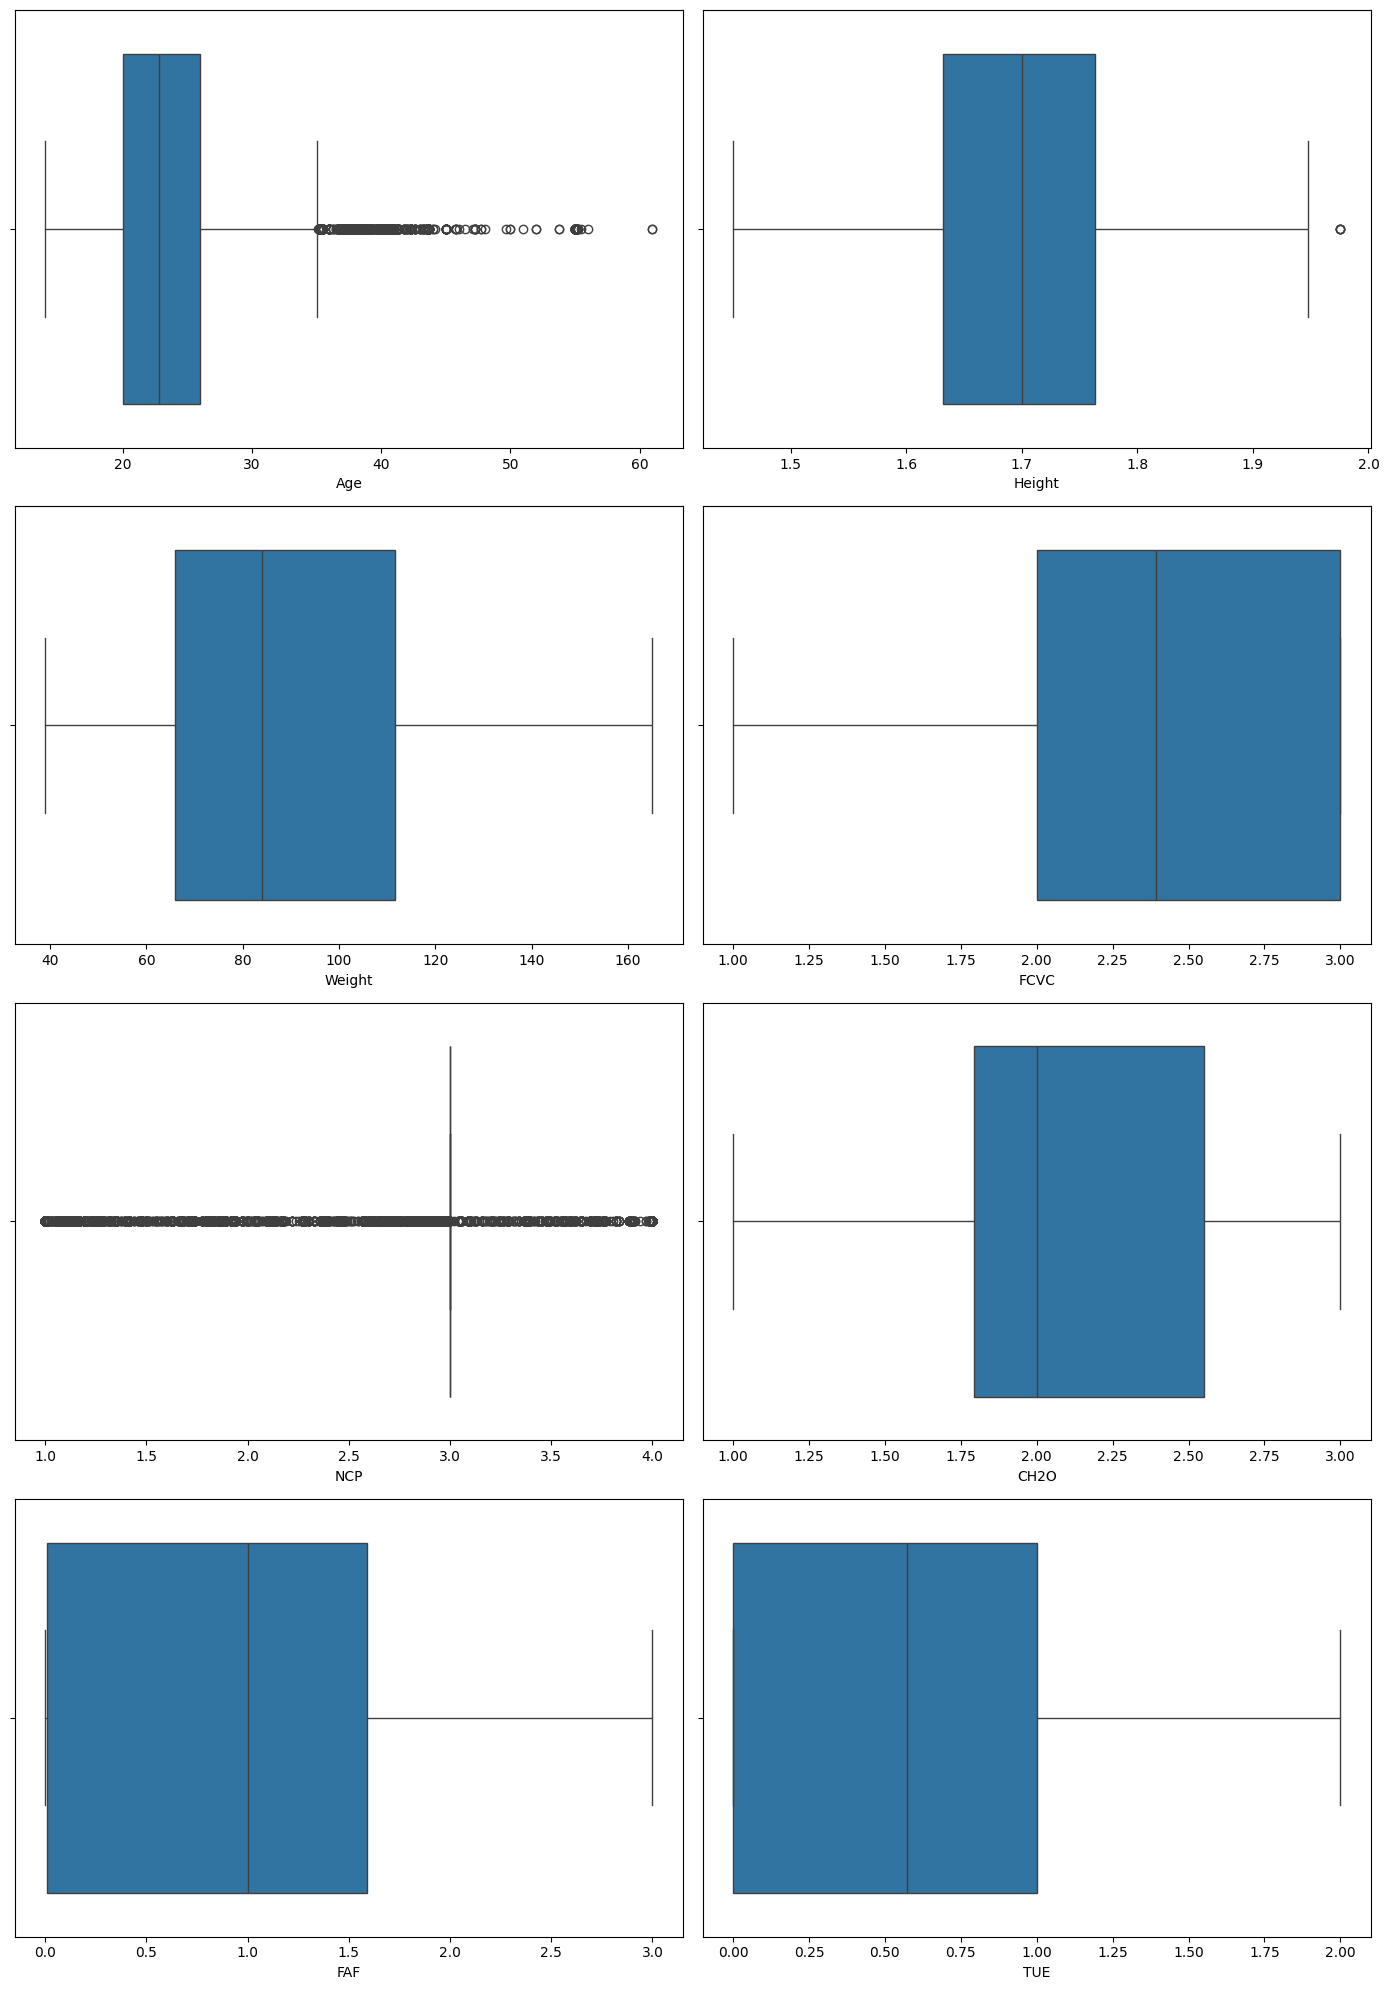

In [15]:
numerical_columns = df.select_dtypes(include=['number']).columns.to_list()
numerical_columns.remove('id')

cols = 2
rows = math.ceil(len(numerical_columns) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(14, 5*rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.boxplot(data=df, x=col, ax=ax)


plt.tight_layout()
plt.show()


### Check Numerical Columns Correlations with the Target Column

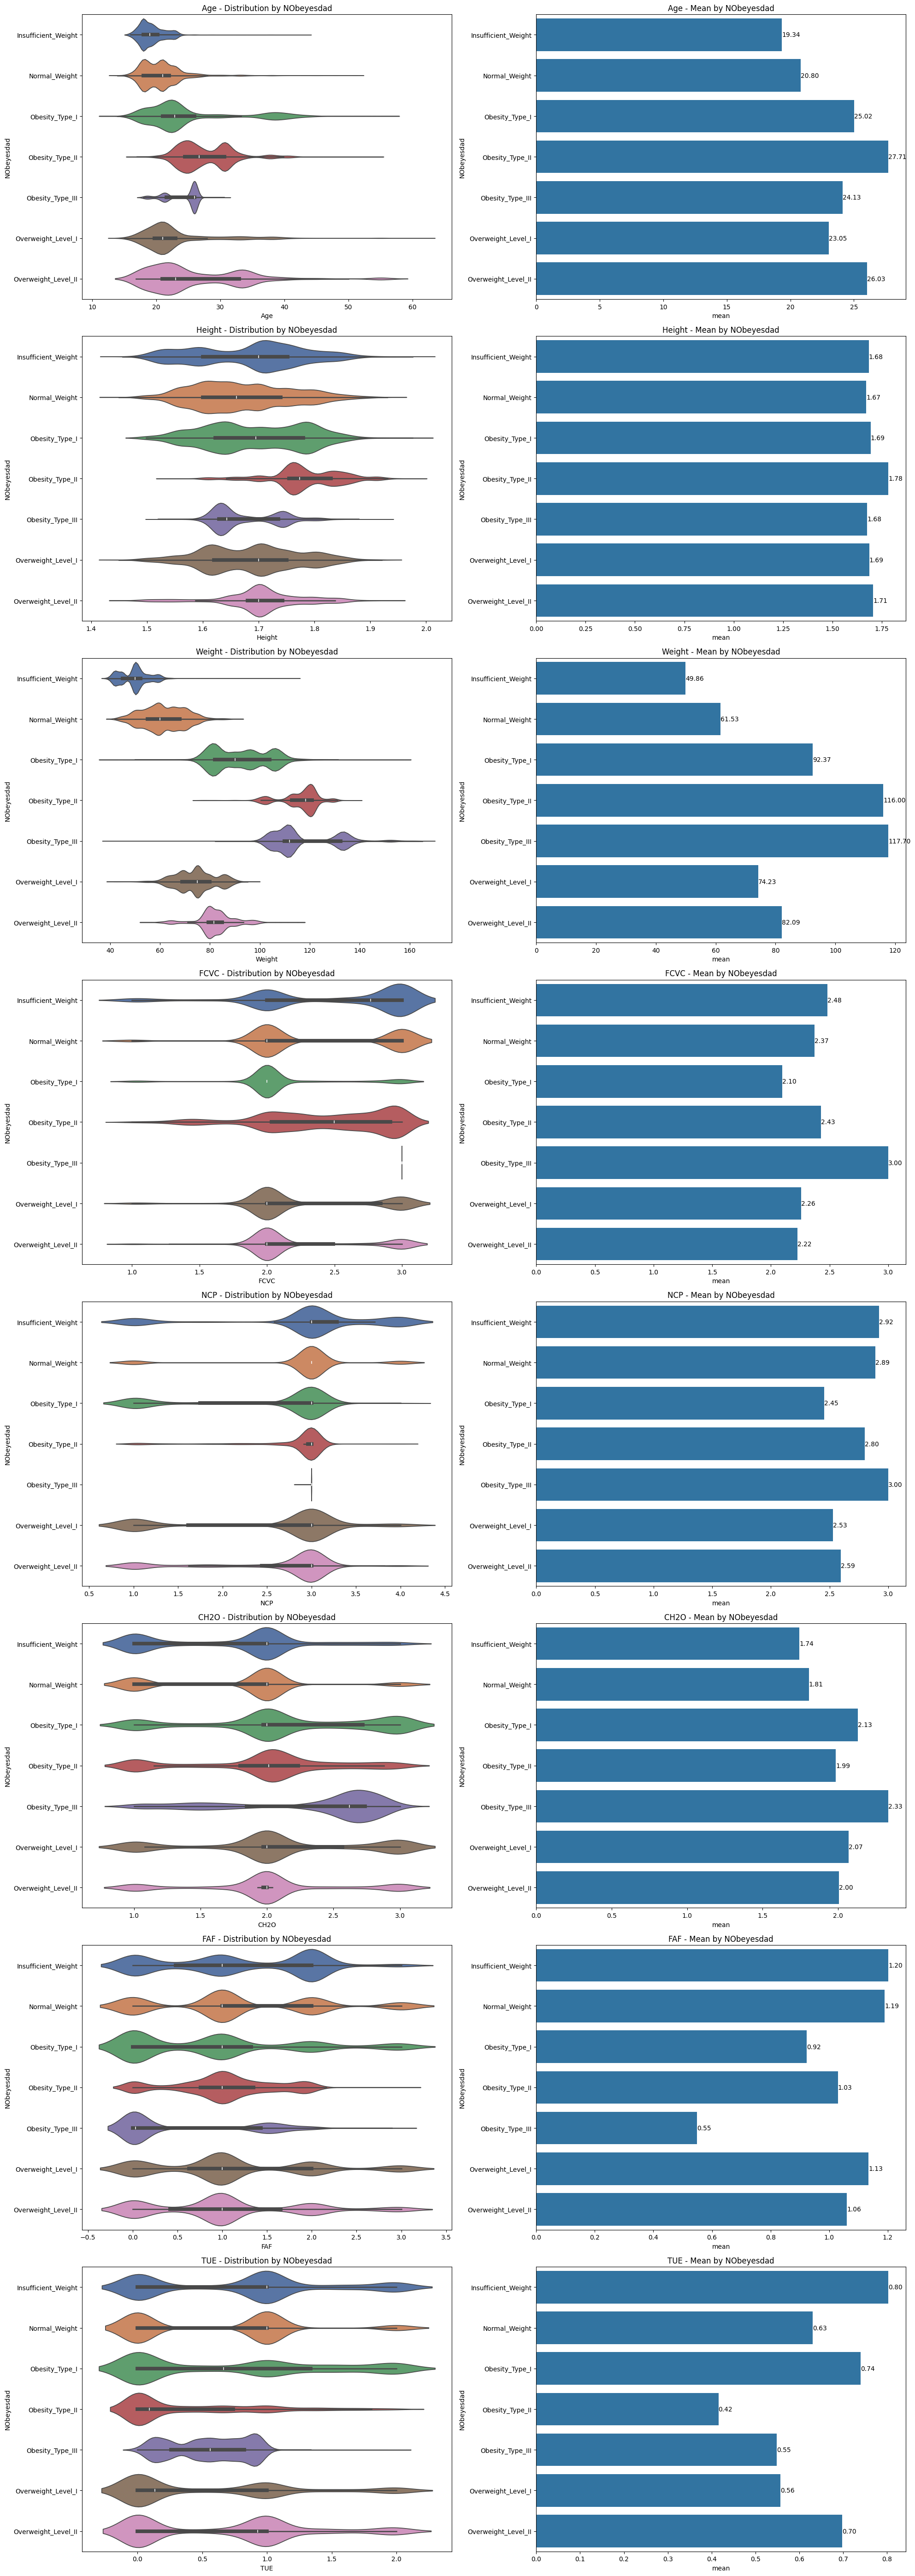

In [16]:

numerical_columns = df.select_dtypes(include=['number']).columns.to_list()
numerical_columns.remove('id')

cols = 2
rows = len(numerical_columns)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, 7*rows))
axes = axes.flatten()

target_column = 'NObeyesdad'
df_cp = df.sort_values(target_column, ascending=True).reset_index(drop=True).copy()

for i, col in enumerate(numerical_columns):
    ax_violin = axes[2*i]
    ax_bar = axes[2*i + 1]

    sns.violinplot(
        data=df_cp,
        x=col,
        y=target_column,
        palette=sns.color_palette("deep"),
        ax=ax_violin
    )
    ax_violin.set_title(f"{col} - Distribution by {target_column}")

    stats = df_cp.groupby(target_column).agg(
        mean=(col, "mean"),
        std=(col, "std")
    ).reset_index()

    sns.barplot(
        data=stats,
        x="mean",
        y=target_column,
        ax=ax_bar
    )
    ax_bar.set_title(f"{col} - Mean by {target_column}")

    for container in ax_bar.containers:
        ax_bar.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()


### Check Categorical Columns Correlations with the Target Column

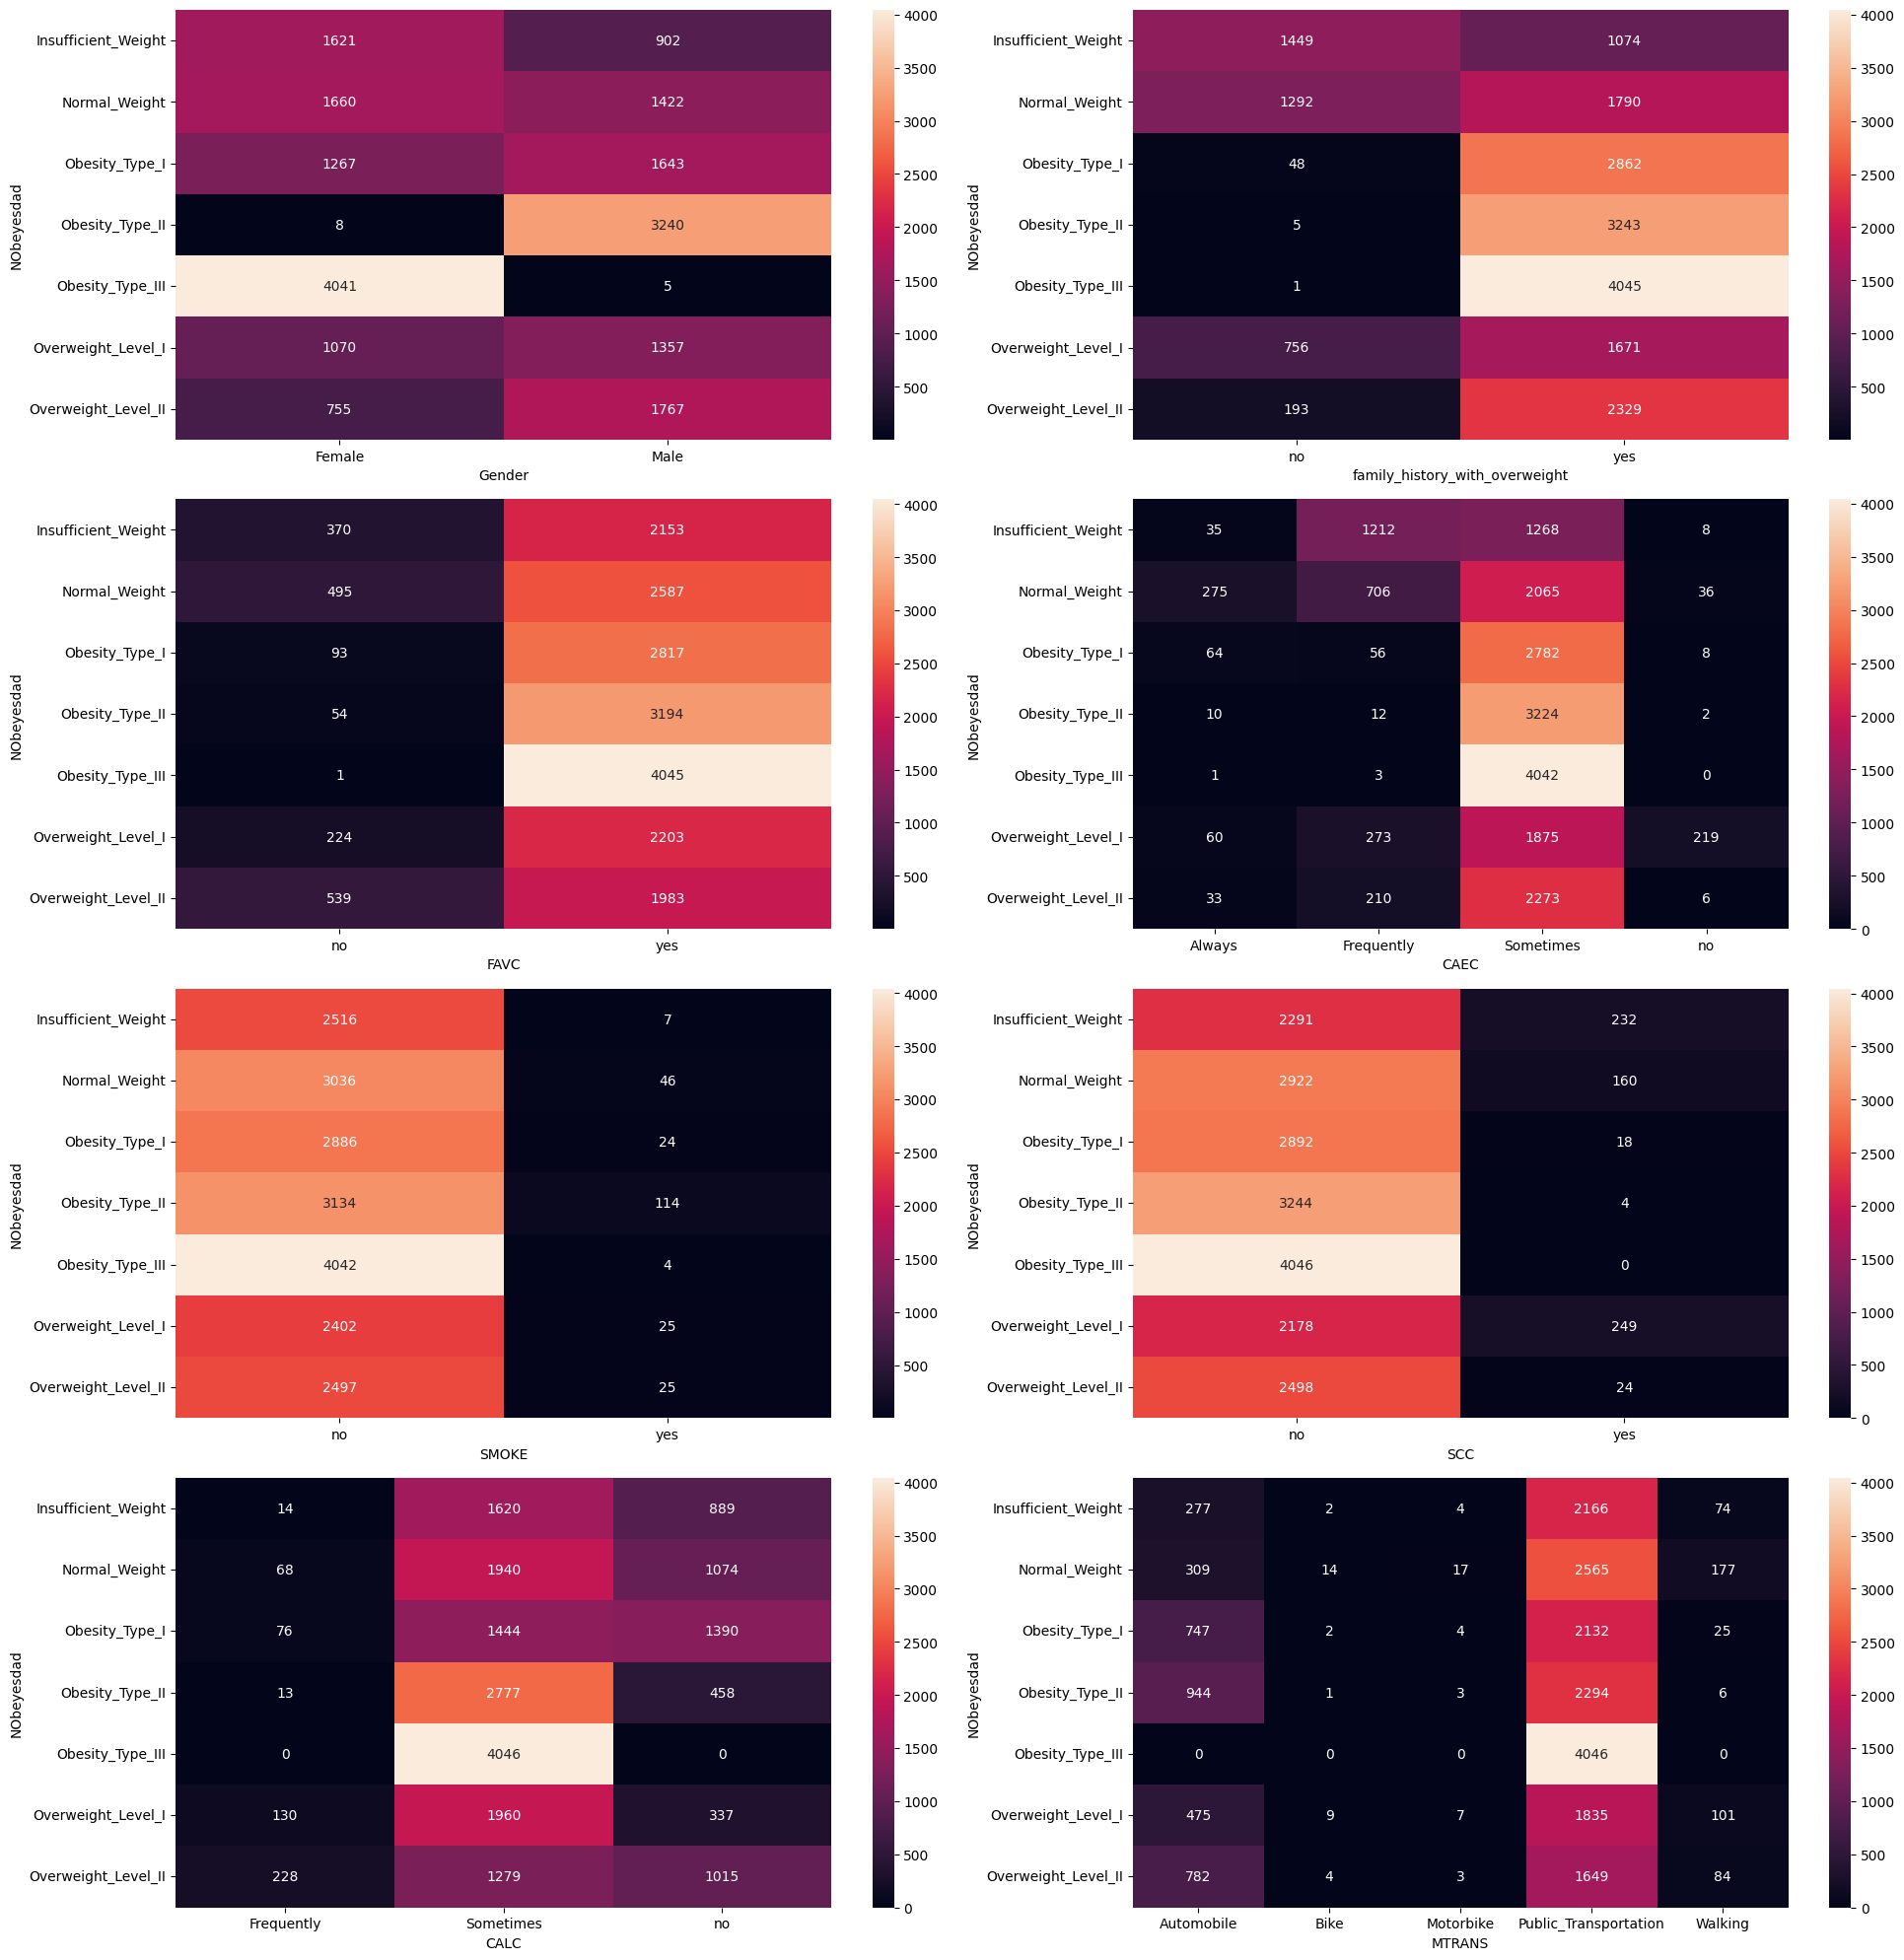

In [17]:
target_column = "NObeyesdad"
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns.remove(target_column)

cols = 2
rows = math.ceil(len(categorical_columns) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, 5*rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    crosstab = pd.crosstab(df[target_column], df[col])
    sns.heatmap(data=crosstab, annot=True, fmt="g", cmap="rocket",ax=ax)

plt.tight_layout()
plt.show()


## Feature Engineering

In [18]:
def plot_numerical_column_per_target(
    column: str,
    df: pd.DataFrame
) -> None:
    stats = df.groupby(target_column).agg(
        mean=(column, "mean"),
        median=(column, "median"),
        std=(column, "std")
    ).reset_index()

    fig, axs = plt.subplots(1, 2, figsize=(20, 7))
    axs = axs.flatten()

    sns.violinplot(
        data=df,
        x=column,
        y=target_column,
        hue=target_column,
        ax=axs[0]
    )
    axs[0].set_xlabel(column)
    axs[0].set_title(f"{column} Violin Plot per Target Class")

    sns.barplot(
        data=stats,
        x="mean",
        y=target_column,
        ax=axs[1]
    )
    axs[1].set_xlabel(column)
    axs[1].set_title(f"Mean {column} per Target Class")

    for i in axs[1].containers:
        axs[1].bar_label(i)

    fig.tight_layout()
    fig.show()

### Body Mass Index (BMI)

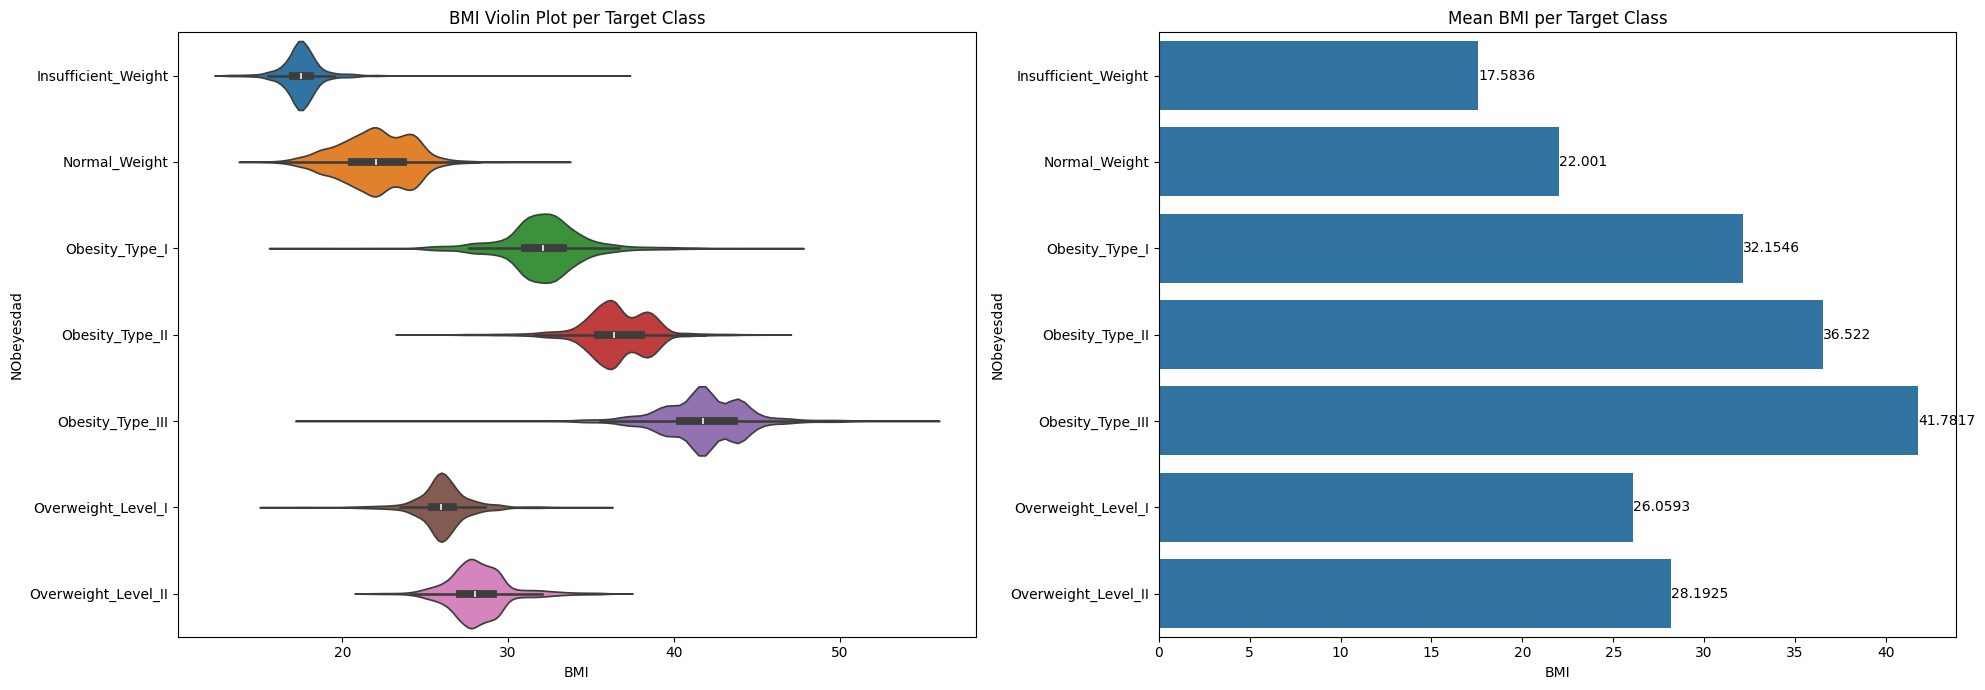

In [19]:
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

temp = df.sort_values(target_column, ascending=True).reset_index(drop=True).copy()

plot_numerical_column_per_target(
    column="BMI",
    df=temp
)

### Ideal Number of Main Meals? (INMM)

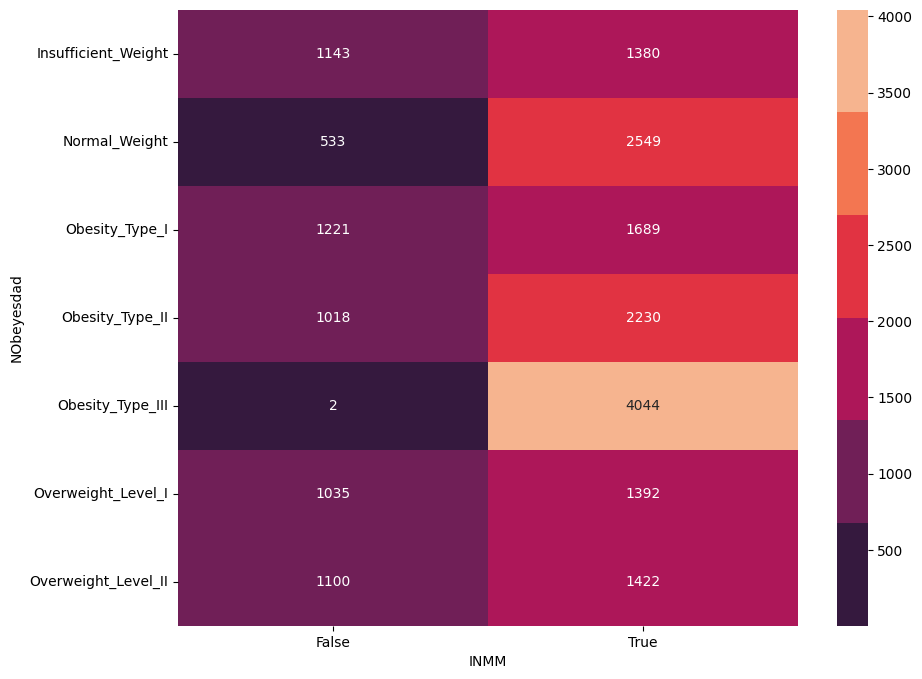

In [20]:
df["INMM"] = df["NCP"] == 3

crosstab = pd.crosstab(df[target_column], df["INMM"])

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab, annot=True, fmt="g", cmap=sns.color_palette("rocket"))
plt.show()


In [21]:
os.remove(RAW_FILE_NAME)